In [6]:
import festim as F


In [7]:
model_2D = F.Simulation()
#model_2D.log_level = 20
model_2D.mesh = F.MeshFromXDMF(volume_file = "/Users/fj1628/Downloads/2DGeometries/DIVMON/DIVMON_volume_mesh.xdmf" , boundary_file="/Users/fj1628/Downloads/2DGeometries/DIVMON/DIVMON_surface_mesh.xdmf")


Succesfully load mesh with 6370 cells


In [8]:
tungsten = F.Material(
    id=31,
    D_0=1.5e-07,  # m2/s
    E_D=0.265,  # eV
    S_0=2.7e24,
    E_S=1.14,
    borders=[0,5e-3],
    thermal_cond=173,  # W/mK
)

copper = F.Material(
    id=30,
    D_0=6.6e-7,
    E_D=0.387,
    S_0=3.14e24,
    E_S=0.572,
    borders=[5e-3, 6e-3],
    thermal_cond=350,
)

cucrzr = F.Material(
	id=29, 
	D_0=4.8e-7, 
	E_D=0.42, 
	S_0=4.27e23, 
	E_S=0.39,
	borders=[6e-3, 8e-3],
	thermal_cond=320
)

model_2D.materials = [tungsten, copper, cucrzr]

In [9]:
w_density = 6.3e28  # atom/m3  
copper_density = 9.2e28
cucrzr_density = 9.2e28  

damage_percent = 0.01 # 0.1-2 dpa/fpy W neutronic damage

trap_W_1 = F.Trap( 
	k_0 = [1.5e-7/((1.1e-10)**2 * 6 * w_density),6.6e-7 / ((3.6e-10)**2 * 1 * copper_density),4.8e-7 / ((3.6e-10)**2 * 1 * cucrzr_density)],
	E_k= [0.265,0.387,0.418],
	p_0=[1.2397e13,5.0926e12,7.3472e12],
	E_p=[0.83,0.5,0.53], 
	density = [w_density*0.00118,copper_density*0.00005,3.7e24],
	materials = [tungsten,copper,cucrzr]
)
            
trap_W_2 = F.Trap(
	k_0 = 1.5e-7/((1.1e-10)**2 * 6 * w_density),
	E_k= 0.265, 
	p_0=1.2397e13,
	E_p=0.97,
	density = w_density*0.000722,
	materials = [tungsten]
)

trap_W_3 = F.Trap(
	k_0=1.5e-7/(1.1e-10**2 * 6 * w_density),
	E_k=0.265,
	p_0=1e13,
	E_p=1.51, # change to 2.05 when necessary
	density = damage_percent*w_density,
	materials = tungsten
) 
model_2D.traps = [trap_W_1, trap_W_2, trap_W_3]

In [10]:
model_2D.T = F.HeatTransferProblem(transient=False)

model_2D.boundary_conditions = [
    F.ImplantationDirichlet(surfaces=32, phi=0.23e24, R_p=1.1e-9, D_0=1.5e-07, E_D=0.265), # mean depth may be too low, maybe order of magnitude higher
    F.DirichletBC(surfaces=36, value=0, field=0),
  #  F.FluxBC(surfaces=32, value=10e6, field="T"),
    F.DirichletBC(surfaces=32, value=1073, field="T"),
    F.DirichletBC(surfaces=36, value=773, field="T"), # Set coolant temp to 573K as 473K messes it up for some reason
]
# boundary conditions on the left (plasma facing) side can be defined as having fixed temperature
# of 1273K using DirichletBC or a heat flux of 12e6 using FluxBC. The value of heat flux needs to
# be order of magnitude higher than what Dinusha initially said (1.2e6) to see saturation in 500 days.
# Localised heating may be much higher than calculated so the design case is 10 MW/m2. 

#model_2D.sources = [ 
		#F.Source(value=28.8e6, volume=31, field='T'), # Neutronic heating W: 1.3-28.8 MW/m3
		#F.Source(value=8.1e6, volume=[30, 29], field='T'), # Neutronic heating Cu & CuCrZr: 0.3-8.1 MW/m3
#]
		
# Stepsize
model_2D.dt = F.Stepsize(
    initial_value=1e1,
    stepsize_change_ratio=1.1,
    dt_min = 0.0005
)


# Settings
model_2D.settings = F.Settings(
    absolute_tolerance=1e12, relative_tolerance=1e-10, final_time=1e8, # relative tolerance has been greatly decreased
    # if you get the float error, change the flux value (phi) in ImplantationDirichlet to a lower magnitude instead of
    # changing tolerance values.
    chemical_pot=True, traps_element_type="DG"
)

retention_1 = F.TotalVolume("retention", volume = 31)
retention_2 = F.TotalVolume("retention", volume = 30)
retention_3 = F.TotalVolume("retention", volume = 29)
solute_1 = F.TotalVolume("solute", volume = 31)
solute_2 = F.TotalVolume("solute", volume = 30)
solute_3 = F.TotalVolume("solute", volume = 29)
derived = [retention_1, retention_2, retention_3, solute_1, solute_2, solute_3]





results_folder = "/Users/fj1628/Downloads/2DGeometries/DIVMON"
model_2D.exports = [F.XDMFExport("T", folder=results_folder), 
                    F.XDMFExport("solute", folder=results_folder), 
                    F.XDMFExport("retention", folder=results_folder),
                    F.DerivedQuantities(derived, filename = results_folder + "/derived_qs.csv")]

model_2D.initialise()
model_2D.run()

Defining variational problem heat transfers
Solving stationary heat equation
Defining initial values
Defining variational problem
Defining source terms
Defining boundary conditions
Time stepping...


/Users/fj1628/anaconda3/envs/festim-env-again/lib/python3.11/site-packages/festim/exports/derived_quantities/derived_quantities.py:129: DeprecationWarning: The current derived_quantities title style will be deprecated in a future release, please use show_units=True instead
  warnings.warn(
/Users/fj1628/anaconda3/envs/festim-env-again/lib/python3.11/site-packages/festim/exports/derived_quantities/derived_quantities.py:129: DeprecationWarning: The current derived_quantities title style will be deprecated in a future release, please use show_units=True instead
  warnings.warn(
/Users/fj1628/anaconda3/envs/festim-env-again/lib/python3.11/site-packages/festim/exports/derived_quantities/derived_quantities.py:129: DeprecationWarning: The current derived_quantities title style will be deprecated in a future release, please use show_units=True instead
  warnings.warn(
/Users/fj1628/anaconda3/envs/festim-env-again/lib/python3.11/site-packages/festim/exports/derived_quantities/derived_quantities

100.0 %        1.0e+08 s    Elapsed time so far: 288.3 s


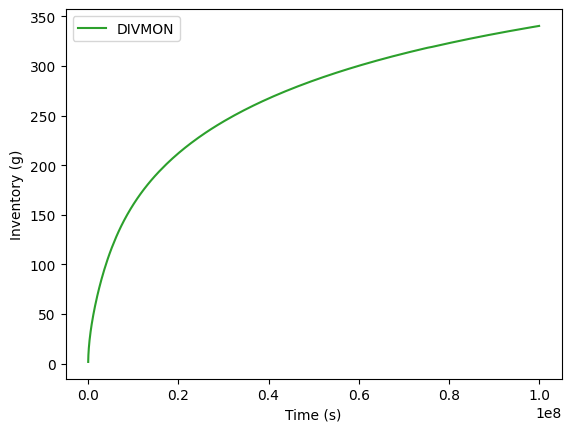

In [11]:
import numpy as np
import matplotlib.pyplot as plt

retention_full = (
    np.array(retention_1.data)
    + np.array(retention_2.data)
    + np.array(retention_3.data)
)


retention_a = retention_full / 6.022e23
retention_b = retention_a / 2
retention_c = retention_b * 3
PFC_area = 5547.2 # m
retention_final = retention_c * PFC_area


time = retention_1.t


plt.plot(retention_1.t, retention_final, label="DIVMON", color="tab:green")
plt.legend()
plt.ylabel("Inventory (g)")
plt.xlabel("Time (s)")

pfc_name = "/DIVMON_GRAPH" 
filepath = results_folder + pfc_name
plt.savefig(filepath)

    
